Daniel Sahputra Manurung (42324015)

Pada kode ini digunakan beberapa library yaitu NumPy untuk membuat dataset dalam bentuk array, Pandas untuk mengolah dan menampilkan data dalam bentuk tabel, linkage dan dendrogram dari Scipy untuk melakukan proses Hierarchical Clustering dan membuat dendrogram, pdist dan squareform untuk menghitung serta menampilkan jarak antar data menggunakan Euclidean Distance, dan Matplotlib untuk menampilkan grafik. Selanjutnya dibuat dataset sederhana yang terdiri dari enam data yaitu a, b, c, d, e, dan f, yang masing-masing memiliki dua nilai sebagai titik koordinat. Setelah dataset dibuat, pdist() digunakan untuk menghitung jarak Euclidean antar semua data, kemudian squareform() mengubah hasil perhitungan tersebut menjadi bentuk Distance Matrix dan disimpan dalam DataFrame agar lebih mudah dibaca. Distance Matrix tersebut kemudian ditampilkan menggunakan print(), sehingga dapat dilihat jarak antara setiap data. Setelah itu, dilakukan proses Hierarchical Clustering menggunakan metode Single Linkage, yaitu pengelompokan data berdasarkan jarak terdekat antar anggota cluster. Hasil clustering disimpan dalam variabel linked, yang kemudian digunakan untuk membuat dendrogram. Pada bagian akhir, grafik diatur ukuran dan judulnya, kemudian label data a sampai f ditampilkan pada dendrogram, sumbu X diberi nama Data Points, sumbu Y diberi nama Distance, serta ditambahkan grid agar grafik lebih mudah dibaca. Terakhir, plt.show() digunakan untuk menampilkan hasil dendrogram dari proses Hierarchical Clustering tersebut.

 === Distance Matrix (Euclidean) === 
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


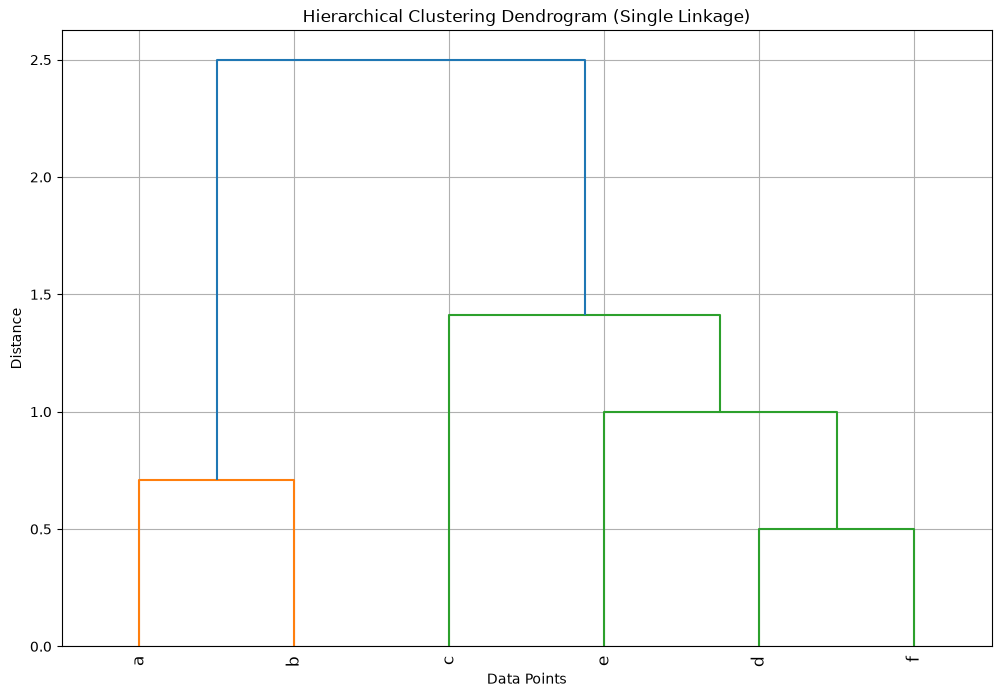

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np. array([
[1.0, 1.0], # a
[1.5, 1.5],
[5.0, 5.0],
[3.0, 4.0],
[4.0, 4.0],
[3.0, 3.5]
])

# b
# c
# d
# e
# f

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
columns=['a', 'b', 'c', 'd', 'e', 'f'],
index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print(" === Distance Matrix (Euclidean) === ")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Pada kode ini library Pandas diimpor untuk digunakan dalam membaca dan mengolah dataset. Selanjutnya, pd.read_csv() digunakan untuk membaca file Mall_Customers.csv yang berada pada lokasi folder yang sudah ditentukan, kemudian data yang sudah dibaca disimpan ke dalam variabel df. Setelah itu, df.head() digunakan untuk menampilkan beberapa baris pertama dari dataset sehingga dapat melihat isi awal data dan memastikan bahwa file berhasil dibaca dengan benar sebelum digunakan pada proses Hierarchical Clustering berikutnya. Kode ini merupakan tahap awal pada percobaan kedua, yaitu menggunakan dataset Mall Customers untuk melakukan pengelompokan pelanggan berdasarkan fitur yang akan dipilih.

In [3]:
import pandas as pd
df = pd.read_csv("C:\PERKULIHAAN\SEMESTER 5\CERTAN\CERTAN\week 5\sesi 3\Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Pada kode ini df.iloc[:, [3, 4]].values digunakan untuk mengambil kolom ke-4 dan ke-5 dari dataset Mall Customers, yaitu Annual Income (k$) dan Spending Score (1-100), kemudian hasilnya disimpan ke dalam variabel x. Setelah itu, StandardScaler dari Scikit-learn digunakan untuk melakukan standardisasi data, dengan membuat objek data_scaler sebagai alat untuk melakukan proses tersebut. Selanjutnya, fit_transform(x) digunakan untuk menghitung dan mengubah nilai pada kedua fitur tersebut ke skala yang sudah distandarkan, kemudian hasilnya disimpan dalam scaled_data. Terakhir, scaled_data.shape digunakan untuk melihat ukuran data setelah proses standardisasi, yang pada praktikum ini menghasilkan (200, 2), artinya terdapat 200 data pelanggan dan 2 fitur yang digunakan dalam proses clustering.

In [4]:
x = df.iloc[:, [3, 4]].values

from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Pada kode ini, linkage dan dendrogram diimpor dari scipy.cluster.hierarchy untuk digunakan dalam proses Hierarchical Clustering dan pembuatan dendrogram. Selanjutnya, linkage() digunakan untuk melakukan proses clustering terhadap data yang sudah distandarisasi pada variabel scaled_data. Metode yang digunakan adalah Complete Linkage, sedangkan metric="euclidean" menunjukkan bahwa jarak antar data dihitung menggunakan Euclidean Distance. Hasil proses clustering tersebut kemudian disimpan dalam variabel clustering, yang nantinya digunakan untuk membuat dendrogram pada tahap berikutnya.

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

Pada kode ini, matplotlib.pyplot diimpor sebagai plt untuk digunakan dalam menampilkan visualisasi. Selanjutnya, dendrogram(clustering) digunakan untuk membuat dendrogram berdasarkan hasil proses Hierarchical Clustering yang sebelumnya sudah disimpan dalam variabel clustering menggunakan metode Complete Linkage. Dendrogram ini digunakan untuk melihat bagaimana data pelanggan digabungkan secara bertahap menjadi beberapa kelompok berdasarkan jaraknya. Terakhir, plt.show() digunakan untuk menampilkan hasil dendrogram tersebut dalam bentuk grafik.

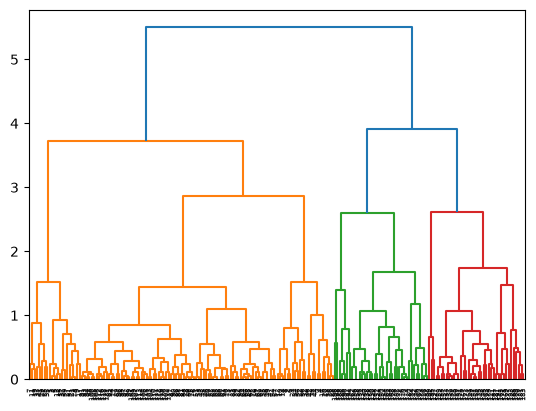

In [6]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

TUGAS 

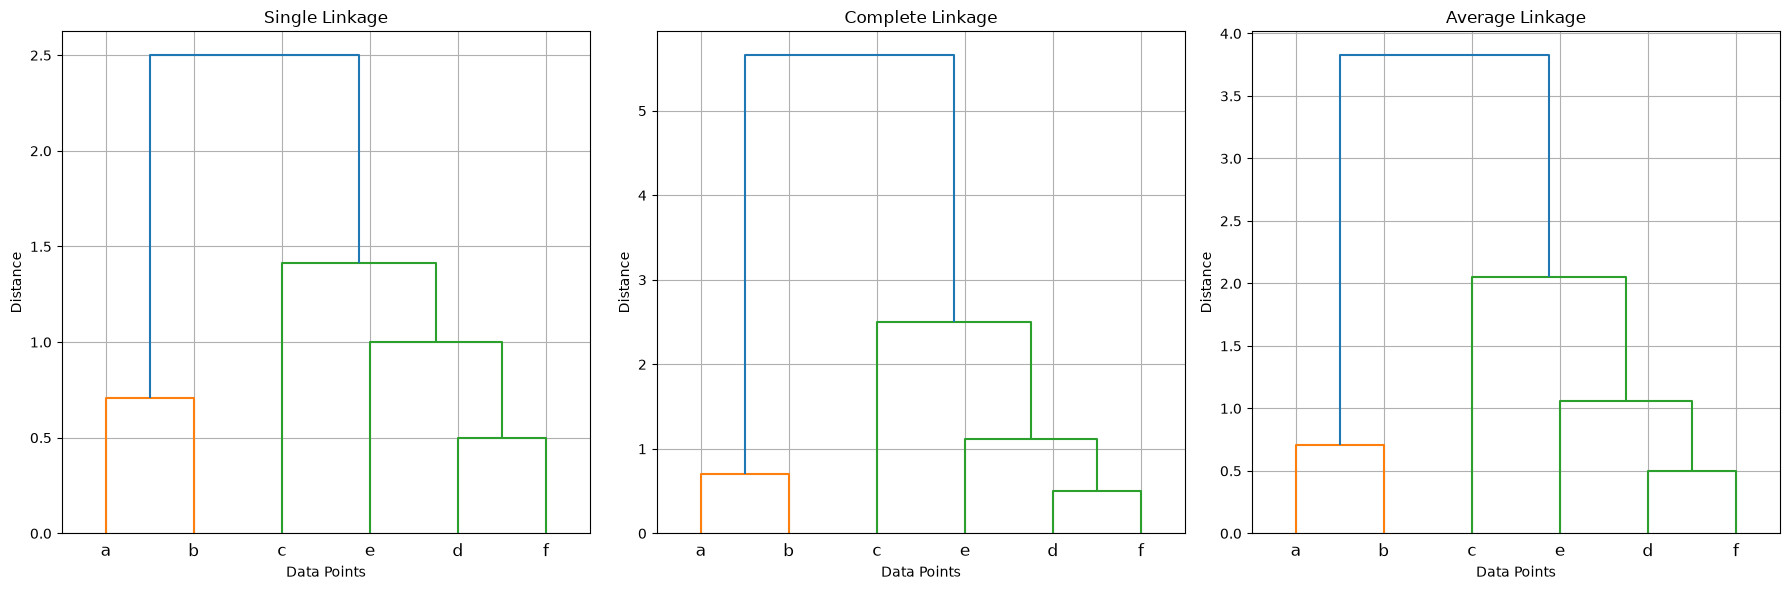

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

# Single Linkage
single = linkage(data, method='single', metric='euclidean')

# Complete Linkage
complete = linkage(data, method='complete', metric='euclidean')

# Average Linkage
average = linkage(data, method='average', metric='euclidean')

# Membuat 3 dendrogram
plt.figure(figsize=(18, 6))

# Single Linkage
plt.subplot(1, 3, 1)
dendrogram(
    single,
    labels=['a', 'b', 'c', 'd', 'e', 'f']
)
plt.title("Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Complete Linkage
plt.subplot(1, 3, 2)
dendrogram(
    complete,
    labels=['a', 'b', 'c', 'd', 'e', 'f']
)
plt.title("Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Average Linkage
plt.subplot(1, 3, 3)
dendrogram(
    average,
    labels=['a', 'b', 'c', 'd', 'e', 'f']
)
plt.title("Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

plt.tight_layout()
plt.show()

Pada percobaan pertama dilakukan perbandingan dendrogram menggunakan tiga metode linkage, yaitu Single Linkage, Complete Linkage, dan Average Linkage. Ketiga metode menggunakan dataset yang sama, sehingga perbedaan hasil dendrogram disebabkan oleh cara masing-masing metode menentukan jarak antar-cluster.

Single Linkage menentukan jarak berdasarkan pasangan data yang memiliki jarak paling dekat. Pada dataset ini, data a dan b memiliki jarak yang sangat dekat, yaitu sekitar 0,707, sedangkan data d dan f memiliki jarak sekitar 0,5. Oleh karena itu, penggabungan cluster pada Single Linkage lebih dipengaruhi oleh data yang paling dekat.

Complete Linkage menggunakan jarak terjauh antar data dalam dua cluster. Metode ini membuat proses penggabungan lebih mempertimbangkan keseluruhan anggota cluster, sehingga cluster yang terbentuk cenderung lebih kompak dibandingkan Single Linkage.

Average Linkage menggunakan rata-rata jarak antar data dari dua cluster. Hasil pengelompokannya berada di antara Single Linkage dan Complete Linkage karena tidak hanya mempertimbangkan jarak terdekat maupun jarak terjauh, tetapi rata-rata jaraknya.

Dengan demikian, ketiga metode dapat menghasilkan struktur dendrogram yang berbeda walaupun menggunakan dataset yang sama. Single Linkage lebih dipengaruhi oleh titik terdekat, Complete Linkage lebih mempertimbangkan titik terjauh, sedangkan Average Linkage menggunakan rata-rata jarak antar-cluster.
